In [2]:
# Credit Card Customer Segmentation
# Step 1 - Import Required Libraries

import warnings
warnings.filterwarnings("ignore")

# Data Handling
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Save Model
import joblib

In [3]:
df = pd.read_csv("../Datasets/CC GENERAL.csv")

df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
df.shape

(8950, 18)

In [5]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [6]:
df.tail()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.50,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.00,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.25,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.25,6
8949,C19190,372.708075,0.666667,1093.25,1093.25,0.00,127.040008,0.666667,0.666667,0.000000,0.333333,2,23,1200.0,63.165404,88.288956,0.00,6


In [7]:
df.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='str')

In [8]:
df.info

<bound method DataFrame.info of      CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0     C10001    40.900749           0.818182      95.40              0.00   
1     C10002  3202.467416           0.909091       0.00              0.00   
2     C10003  2495.148862           1.000000     773.17            773.17   
3     C10004  1666.670542           0.636364    1499.00           1499.00   
4     C10005   817.714335           1.000000      16.00             16.00   
...      ...          ...                ...        ...               ...   
8945  C19186    28.493517           1.000000     291.12              0.00   
8946  C19187    19.183215           1.000000     300.00              0.00   
8947  C19188    23.398673           0.833333     144.40              0.00   
8948  C19189    13.457564           0.833333       0.00              0.00   
8949  C19190   372.708075           0.666667    1093.25           1093.25   

      INSTALLMENTS_PURCHASES  CASH_ADVANCE 

In [9]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [10]:
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.drop("CUST_ID", axis=1, inplace=True)

df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [14]:
df.isnull().sum()

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [15]:
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())

df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())

In [16]:
df.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [18]:
df.shape

(8950, 17)

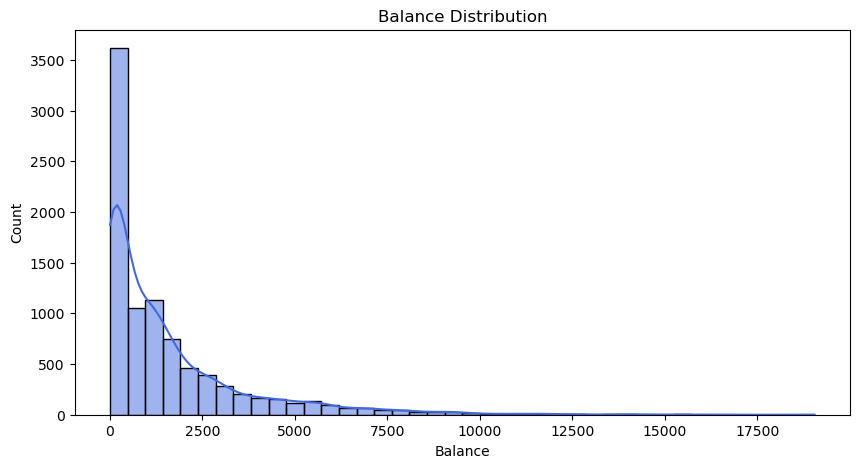

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["BALANCE"],
    bins=40,
    kde=True,
    color="royalblue"
)

plt.title("Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Count")

plt.show()

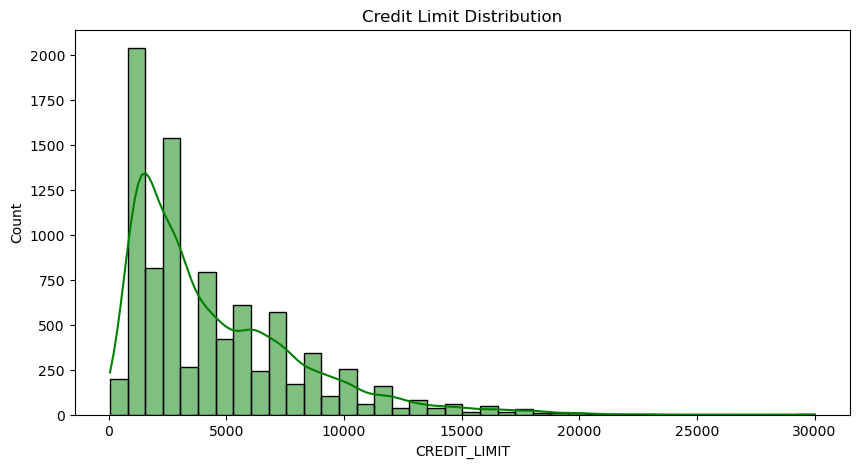

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["CREDIT_LIMIT"],
    bins=40,
    kde=True,
    color="green"
)

plt.title("Credit Limit Distribution")

plt.show()

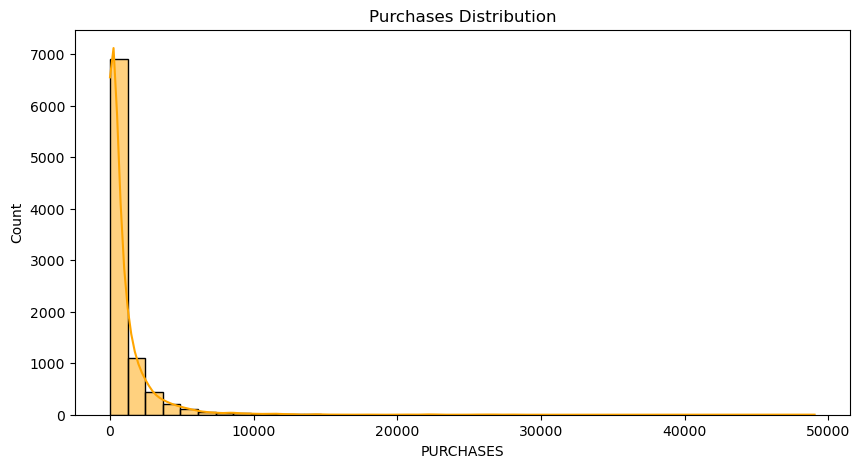

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["PURCHASES"],
    bins=40,
    kde=True,
    color="orange"
)

plt.title("Purchases Distribution")

plt.show()

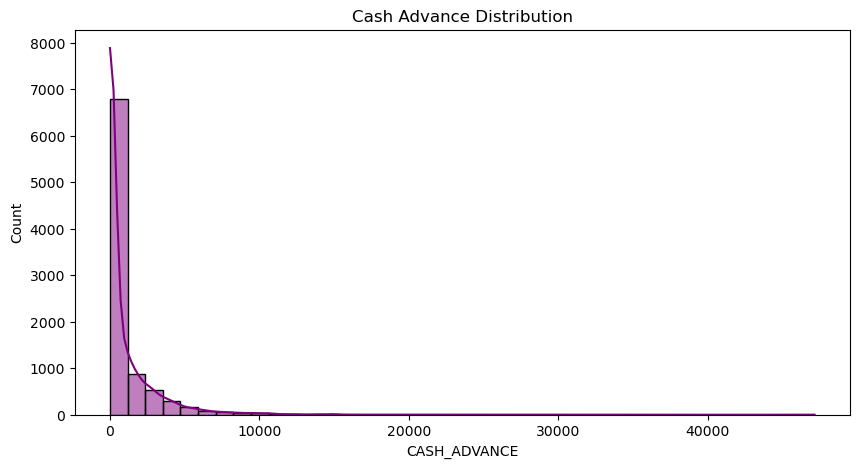

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["CASH_ADVANCE"],
    bins=40,
    kde=True,
    color="purple"
)

plt.title("Cash Advance Distribution")

plt.show()

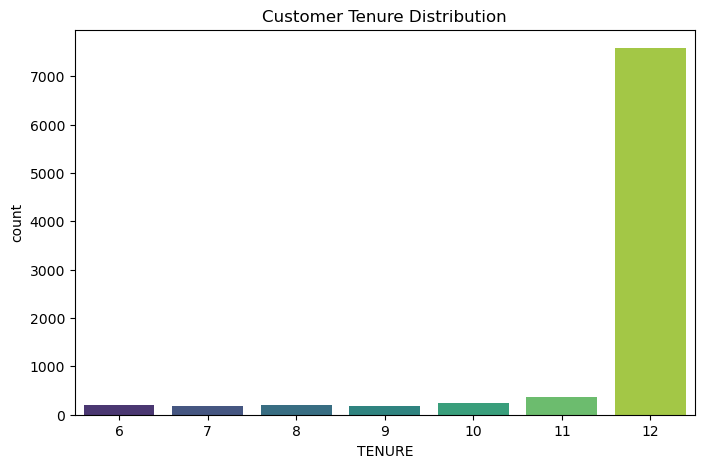

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="TENURE",
    data=df,
    palette="viridis"
)

plt.title("Customer Tenure Distribution")

plt.show()

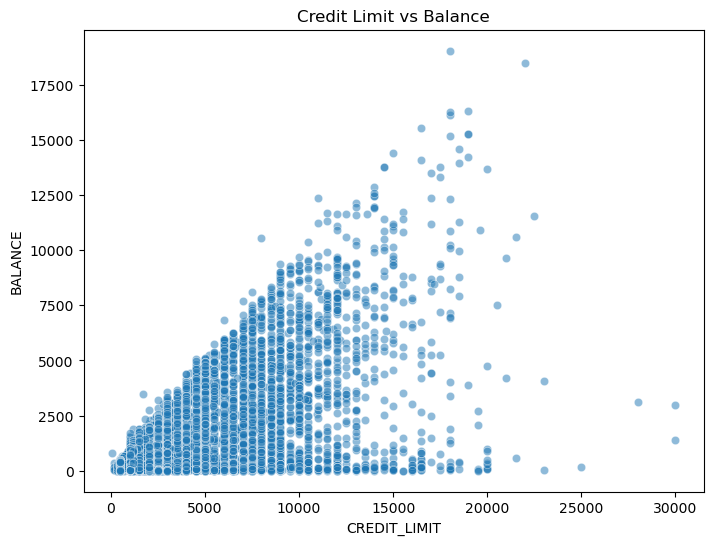

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="CREDIT_LIMIT",
    y="BALANCE",
    data=df,
    alpha=0.5
)

plt.title("Credit Limit vs Balance")

plt.show()

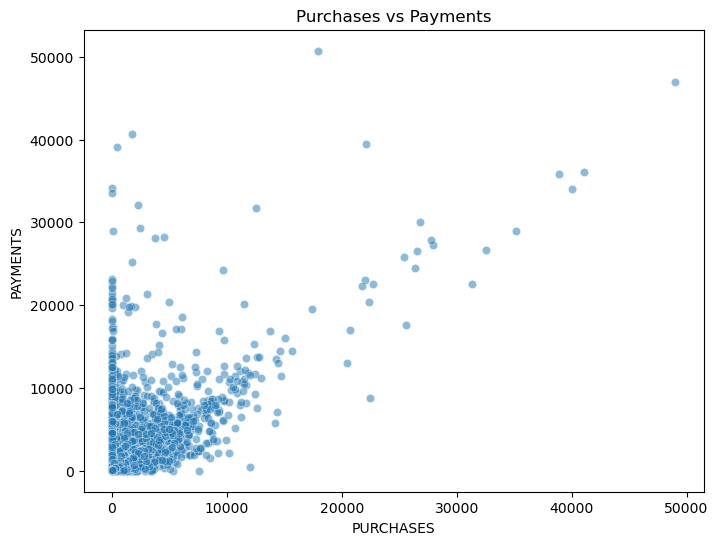

In [25]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PURCHASES",
    y="PAYMENTS",
    data=df,
    alpha=0.5
)

plt.title("Purchases vs Payments")

plt.show()

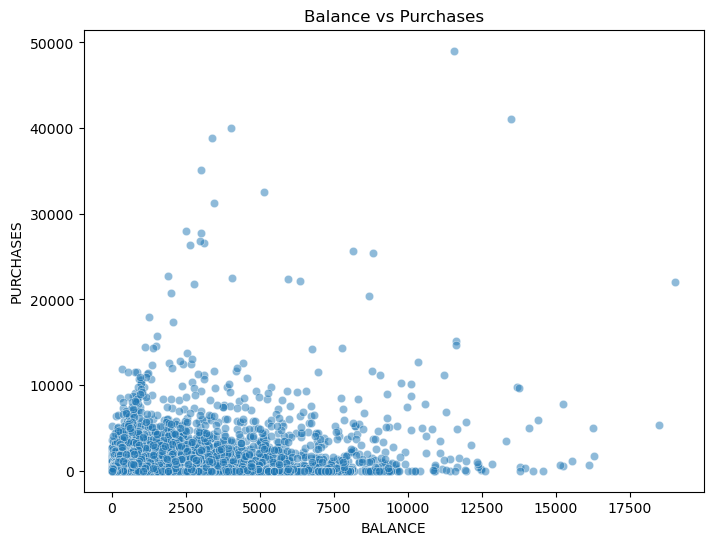

In [26]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="BALANCE",
    y="PURCHASES",
    data=df,
    alpha=0.5
)

plt.title("Balance vs Purchases")

plt.show()

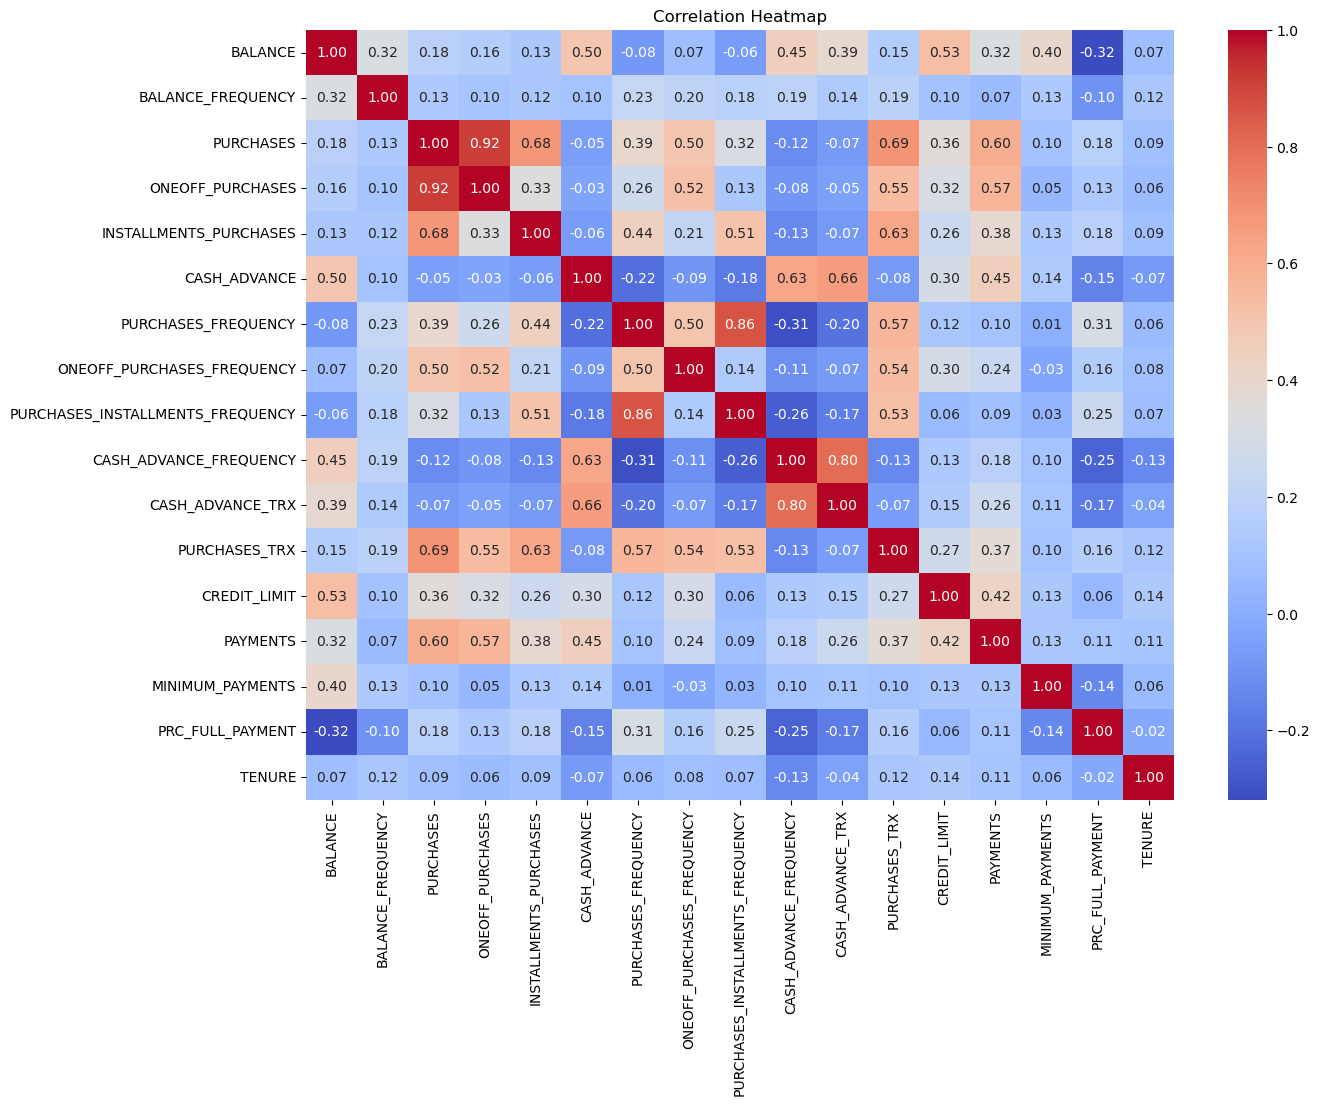

In [27]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

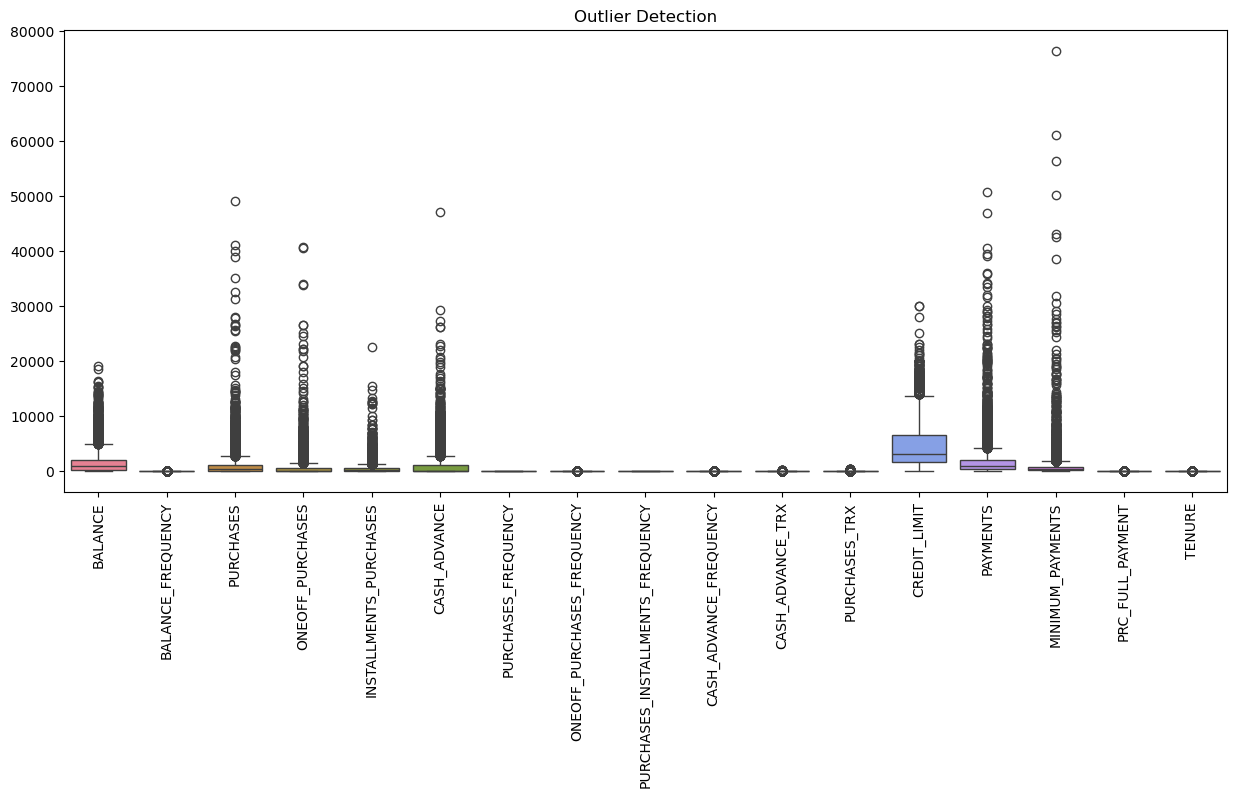

In [28]:
plt.figure(figsize=(15,6))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.title("Outlier Detection")

plt.show()

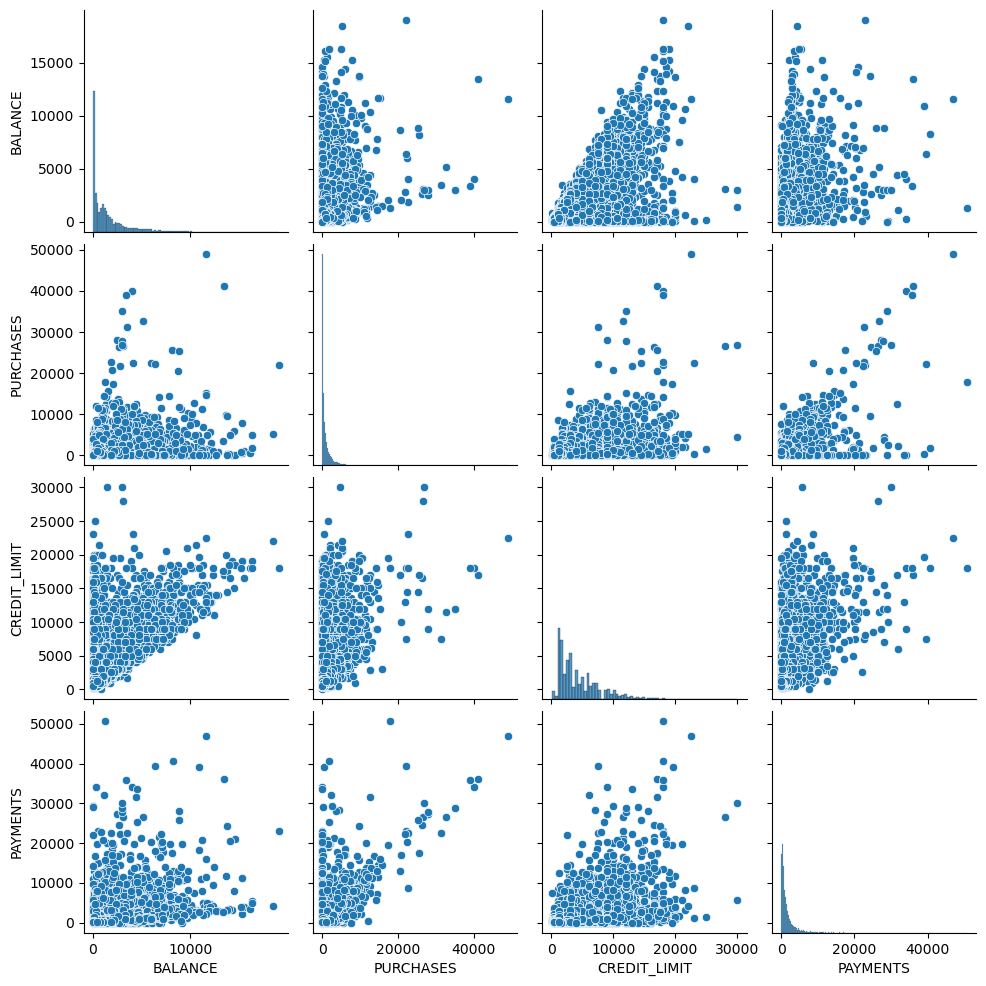

In [29]:
sns.pairplot(
    df[
        [
            "BALANCE",
            "PURCHASES",
            "CREDIT_LIMIT",
            "PAYMENTS"
        ]
    ]
)

plt.show()

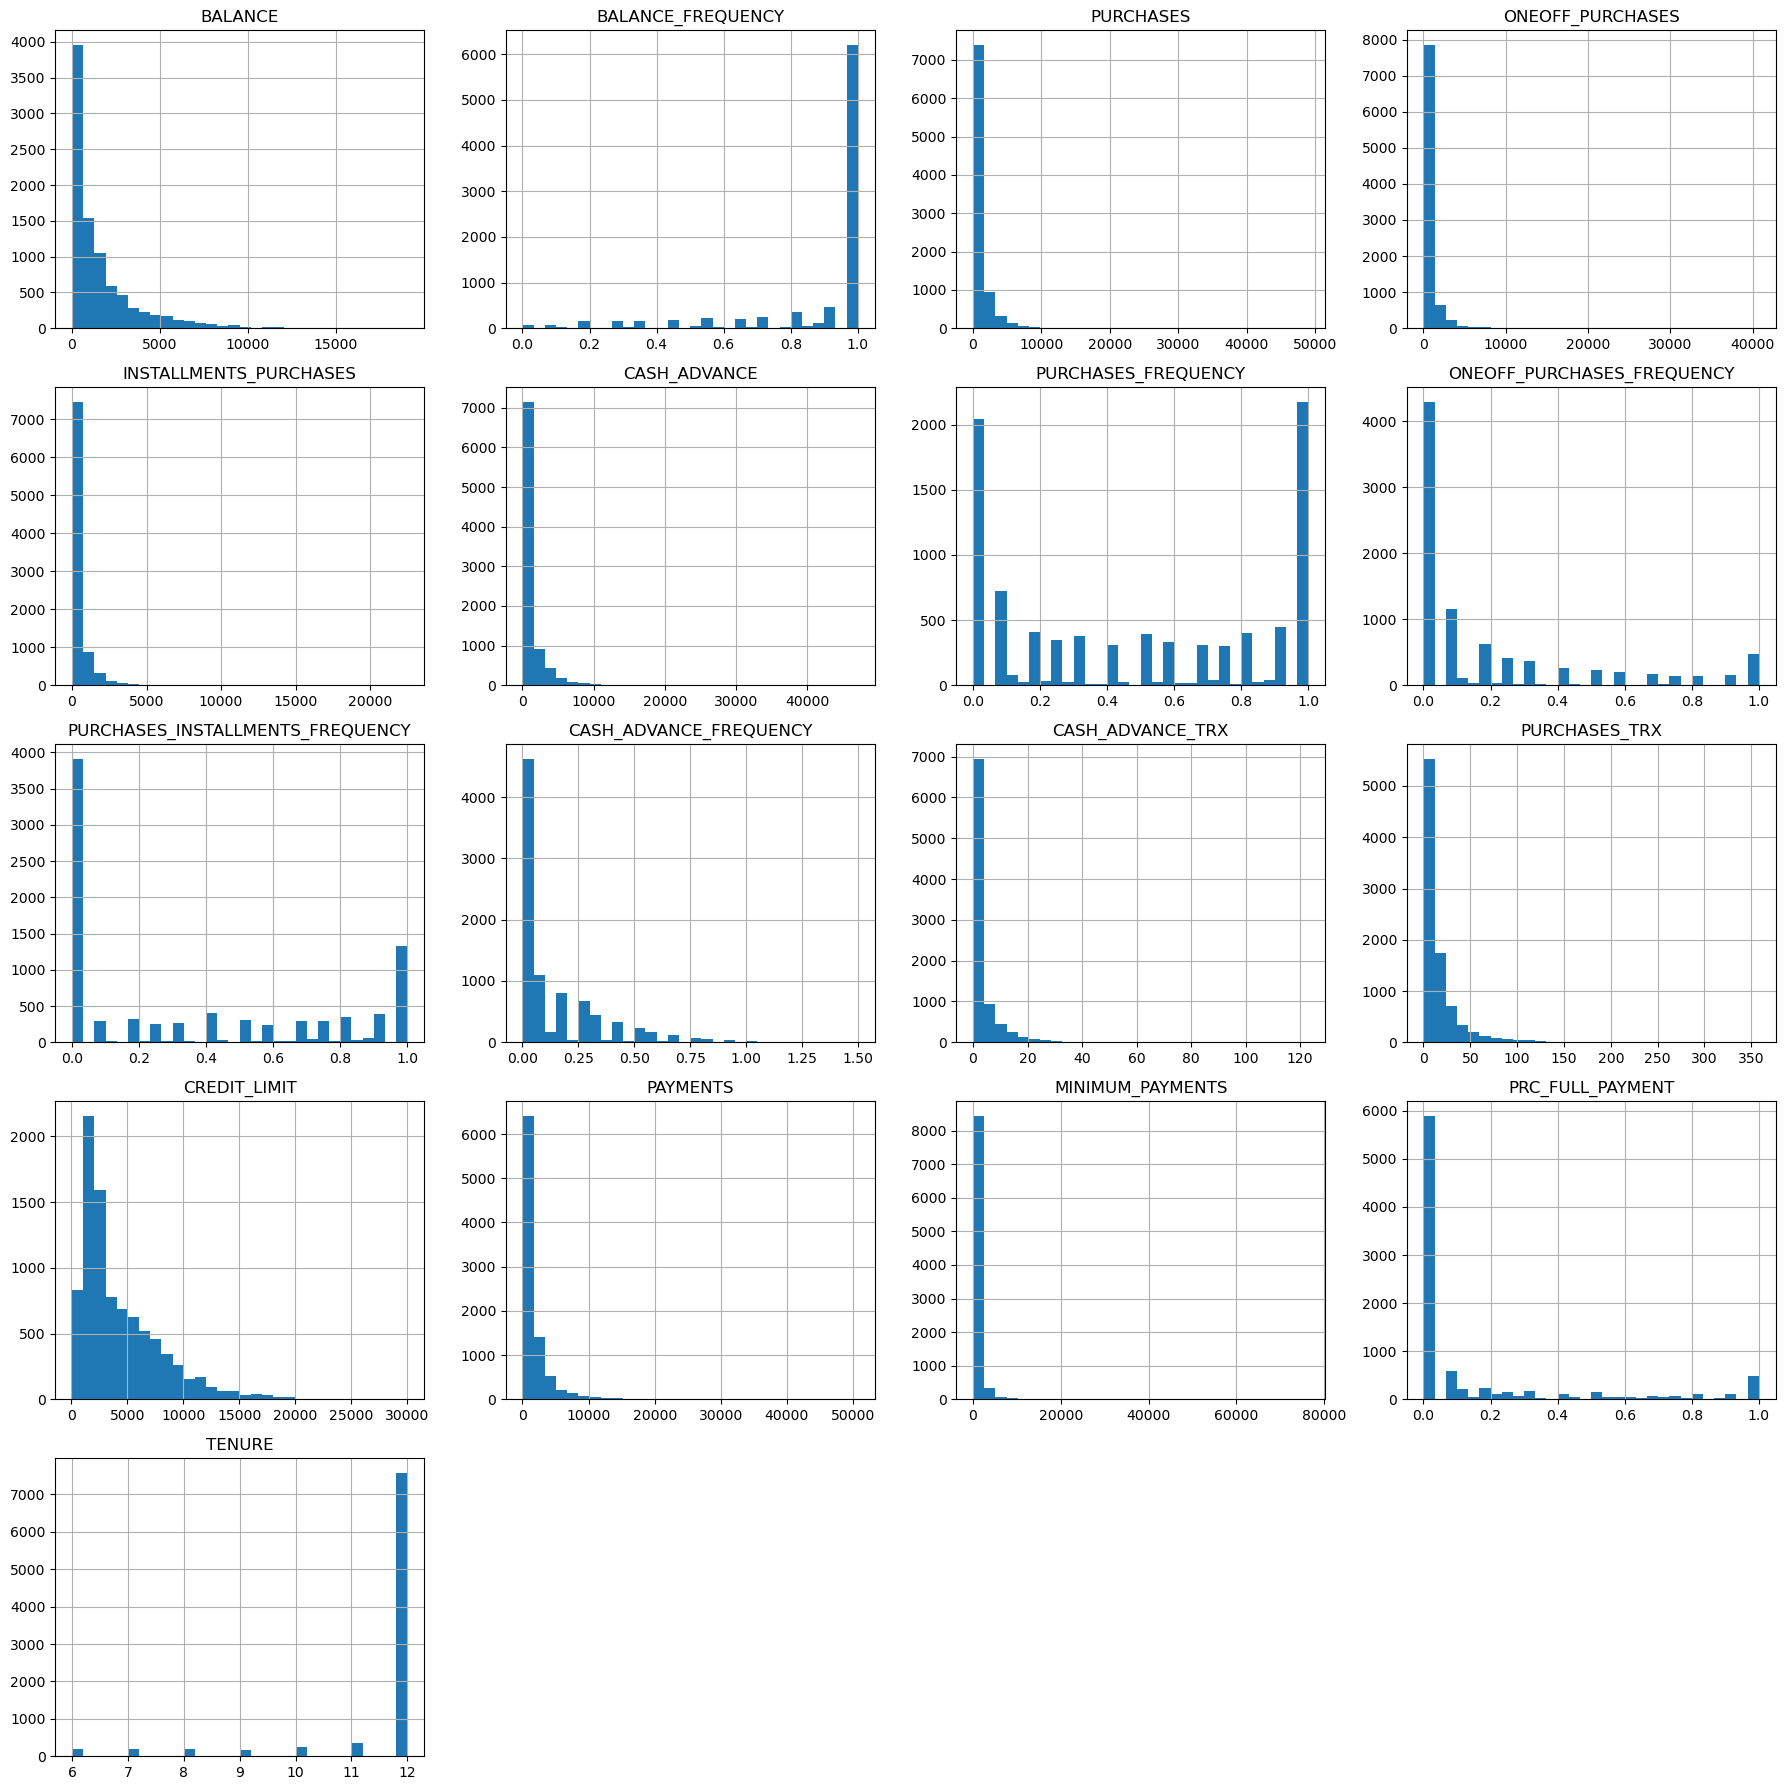

In [30]:
df.hist(
    figsize=(18,18),
    bins=30
)

plt.tight_layout()

plt.show()

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

In [32]:
scaled_df = pd.DataFrame(
    scaled_data,
    columns=df.columns
)

scaled_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


In [33]:
scaled_df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8.950000e+03,8.950000e+03,8950.000000,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8.950000e+03,8950.000000,8.950000e+03
mean,8.891708e-17,2.286439e-16,0.000000,3.175610e-17,2.540488e-17,1.016195e-16,-1.841854e-16,-8.891708e-17,4.604634e-17,5.557317e-17,-2.540488e-17,-2.540488e-17,1.270244e-16,-3.810732e-17,5.716098e-17,0.000000,2.794537e-16
std,1.000056e+00,1.000056e+00,1.000056,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056e+00,1.000056,1.000056e+00
min,-7.516398e-01,-3.703271e+00,-0.469552,-3.569340e-01,-4.545762e-01,-4.667856e-01,-1.221758e+00,-6.786608e-01,-9.169952e-01,-6.753489e-01,-4.760698e-01,-5.917959e-01,-1.221479e+00,-5.986883e-01,-3.621989e-01,-0.525551,-4.122768e+00
25%,-6.900078e-01,4.904486e-02,-0.451001,-3.569340e-01,-4.545762e-01,-4.667856e-01,-1.014125e+00,-6.786608e-01,-9.169952e-01,-6.753489e-01,-4.760698e-01,-5.515646e-01,-7.954727e-01,-4.662913e-01,-2.889613e-01,-0.525551,3.606795e-01
50%,-3.320286e-01,5.180838e-01,-0.300454,-3.340396e-01,-3.561562e-01,-4.667856e-01,2.404259e-02,-3.993193e-01,-4.976286e-01,-6.753489e-01,-4.760698e-01,-3.101767e-01,-4.106928e-01,-3.026846e-01,-2.283069e-01,-0.525551,3.606795e-01
75%,2.352559e-01,5.180838e-01,0.050047,-9.056763e-03,6.366321e-02,6.435242e-02,1.062211e+00,3.269728e-01,9.701506e-01,4.351492e-01,1.100739e-01,9.213645e-02,5.512570e-01,5.802976e-02,-2.408976e-02,-0.037122,3.606795e-01
max,8.397489e+00,5.180838e-01,22.483510,2.420107e+01,2.442689e+01,2.201112e+01,1.269843e+00,2.673451e+00,1.599199e+00,6.820521e+00,1.754785e+01,1.381101e+01,7.010063e+00,1.692228e+01,3.239273e+01,2.893453,3.606795e-01


In [34]:
# Elbow Method

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init="k-means++",
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_df)

    wcss.append(kmeans.inertia_)

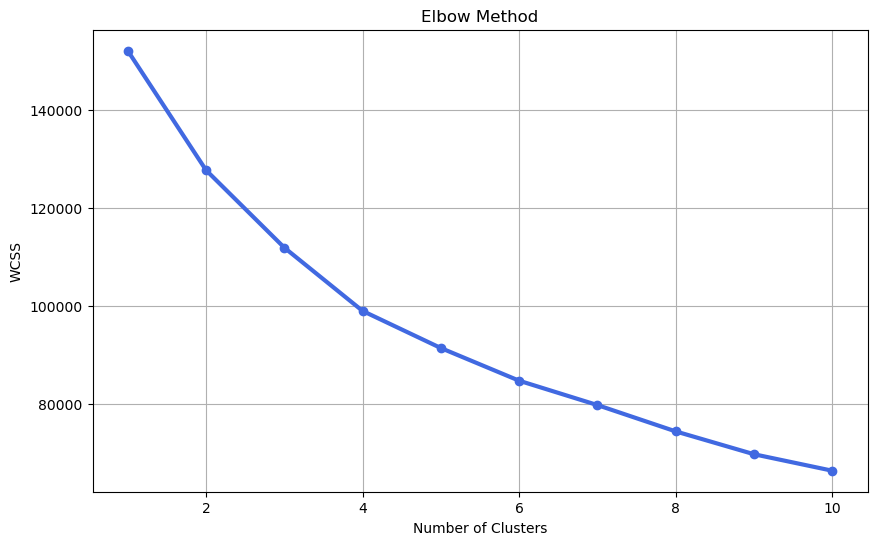

In [35]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1,11),
    wcss,
    marker="o",
    linewidth=3,
    color="royalblue"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [36]:

# Train K-Means Model

kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_df)

In [37]:
df["Cluster"] = clusters

df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,0
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,4
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,1
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,0
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,0


In [38]:
df["Cluster"].value_counts().sort_index()

Cluster
0    3910
1    1385
2      85
3    2415
4    1155
Name: count, dtype: int64

In [39]:
score = silhouette_score(
    scaled_df,
    clusters
)

print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.1931


In [40]:

# PCA
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(
    pca_data,
    columns=["PCA1", "PCA2"]
)

pca_df["Cluster"] = clusters

pca_df.head()

,PCA1,PCA2,Cluster
0,-1.683649,-1.072241,0
1,-1.134085,2.509150,4
2,0.969395,-0.383577,1
3,-0.888220,0.004648,0
4,-1.600021,-0.683795,0


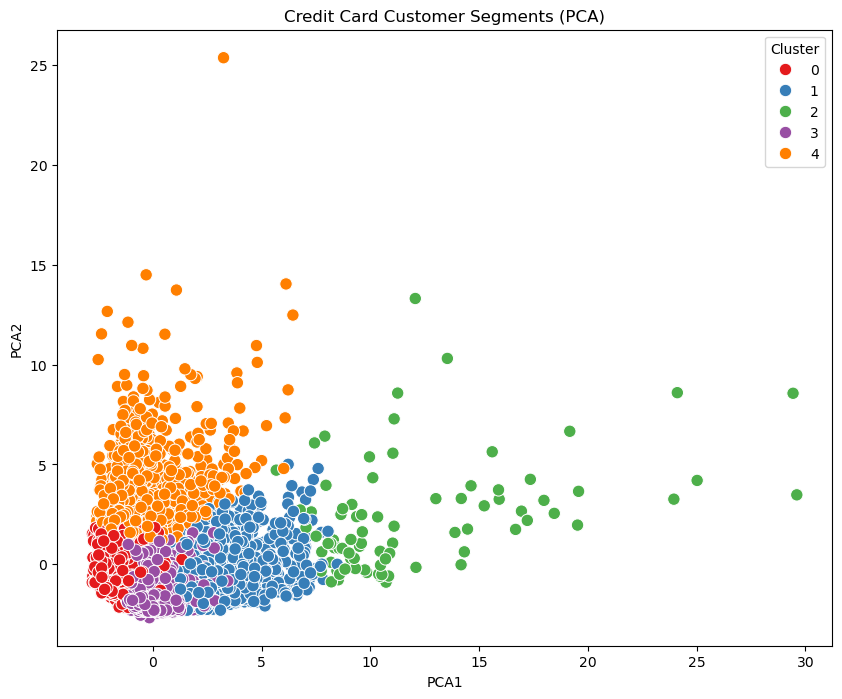

In [41]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set1",
    s=80
)

plt.title("Credit Card Customer Segments (PCA)")

plt.show()

In [42]:
cluster_summary = df.groupby("Cluster").mean()

cluster_summary

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,1050.105528,0.796663,278.943148,225.819926,53.325698,618.399979,0.163437,0.096880,0.065794,0.118196,2.197954,2.951407,3342.971867,1006.225861,557.360084,0.070738,11.457801
1,1904.691069,0.979485,2925.208433,1988.683126,936.958520,360.612509,0.924163,0.733592,0.586192,0.058631,1.172563,43.617329,6986.640630,2789.122842,832.822601,0.265396,11.883755
2,4516.369799,0.976364,15897.090235,10780.888000,5116.202235,1039.836264,0.927255,0.765205,0.778930,0.084314,2.858824,130.435294,12451.764706,15563.997149,3344.425716,0.398384,11.964706
3,644.401406,0.902296,797.100936,167.277110,630.317938,178.022789,0.856389,0.083609,0.793910,0.038031,0.709317,16.642650,3197.600958,935.289177,669.990470,0.271792,11.455072
4,4604.345571,0.967965,485.151896,298.426606,186.813316,4610.556793,0.279340,0.130053,0.181023,0.491062,14.634632,7.293506,7528.748524,3578.091866,2014.610528,0.035796,11.376623


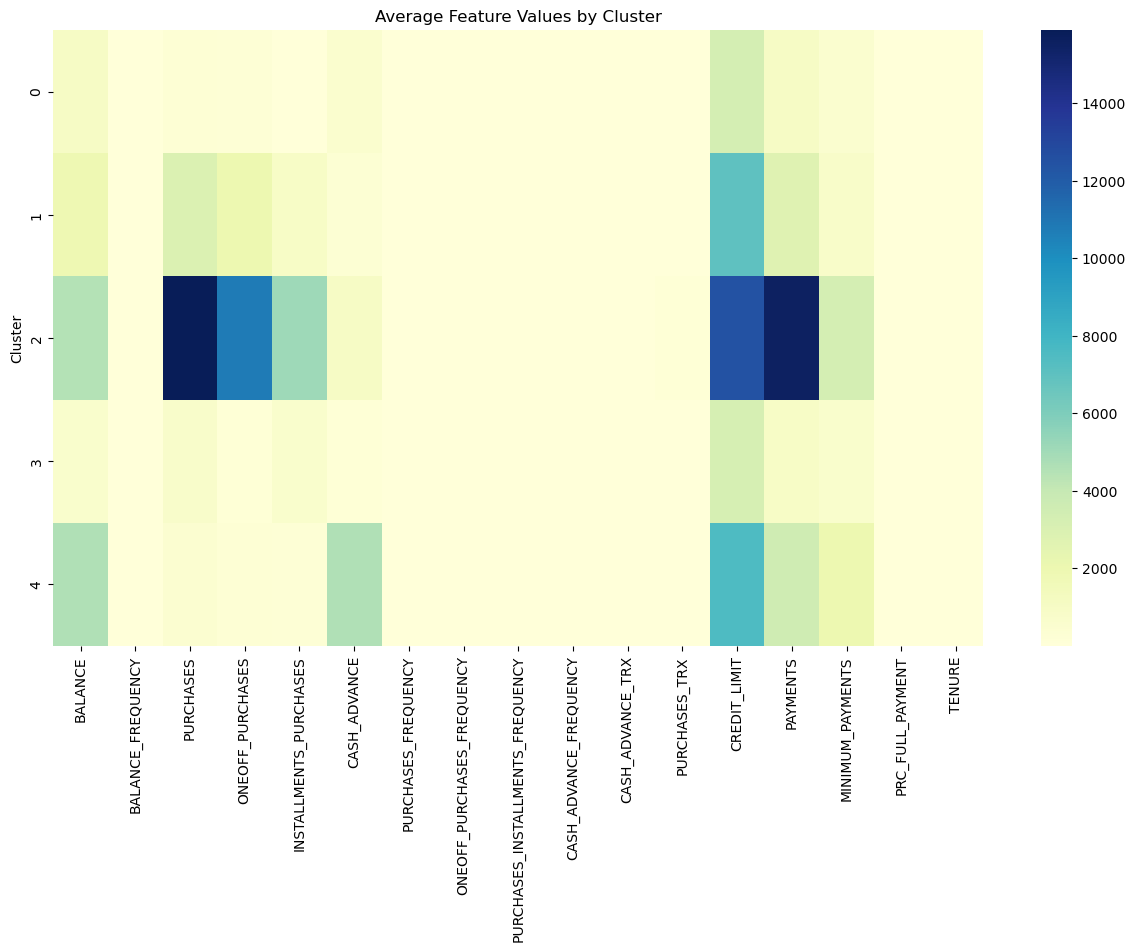

In [43]:
plt.figure(figsize=(15,8))

sns.heatmap(
    cluster_summary,
    cmap="YlGnBu",
    annot=False
)

plt.title("Average Feature Values by Cluster")

plt.show()

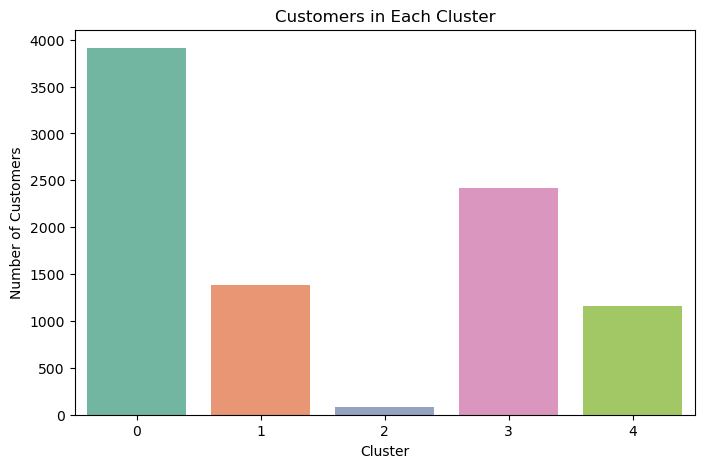

In [44]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Cluster",
    data=df,
    palette="Set2"
)

plt.title("Customers in Each Cluster")

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

In [45]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")

print("✅ K-Means Model Saved Successfully")

✅ K-Means Model Saved Successfully


In [46]:
joblib.dump(scaler, "scaler.pkl")

print("✅ Scaler Saved Successfully")

✅ Scaler Saved Successfully


In [47]:
joblib.dump(pca, "pca_model.pkl")

print("✅ PCA Model Saved Successfully")

✅ PCA Model Saved Successfully


In [48]:
joblib.dump(list(df.drop("Cluster", axis=1).columns), "feature_names.pkl")

print("✅ Feature Names Saved Successfully")

✅ Feature Names Saved Successfully


In [49]:
kmeans_model = joblib.load("kmeans_model.pkl")

scaler_model = joblib.load("scaler.pkl")

feature_names = joblib.load("feature_names.pkl")

In [50]:
print(feature_names)

['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


In [51]:
sample_customer = pd.DataFrame({
    "BALANCE":[1200],
    "BALANCE_FREQUENCY":[1],
    "PURCHASES":[800],
    "ONEOFF_PURCHASES":[300],
    "INSTALLMENTS_PURCHASES":[500],
    "CASH_ADVANCE":[0],
    "PURCHASES_FREQUENCY":[0.8],
    "ONEOFF_PURCHASES_FREQUENCY":[0.4],
    "PURCHASES_INSTALLMENTS_FREQUENCY":[0.7],
    "CASH_ADVANCE_FREQUENCY":[0],
    "CASH_ADVANCE_TRX":[0],
    "PURCHASES_TRX":[18],
    "CREDIT_LIMIT":[4000],
    "PAYMENTS":[1500],
    "MINIMUM_PAYMENTS":[350],
    "PRC_FULL_PAYMENT":[0.6],
    "TENURE":[12]
})

In [52]:
sample_scaled = scaler_model.transform(sample_customer)

In [53]:
cluster = kmeans_model.predict(sample_scaled)

print("Predicted Cluster :", cluster[0])

Predicted Cluster : 3


In [54]:
cluster_names = {
    0: "Premium Customers",
    1: "Frequent Shoppers",
    2: "Balanced Customers",
    3: "High Cash Advance Users",
    4: "Low Activity Customers"
}

print("Customer Segment :", cluster_names[cluster[0]])

Customer Segment : High Cash Advance Users


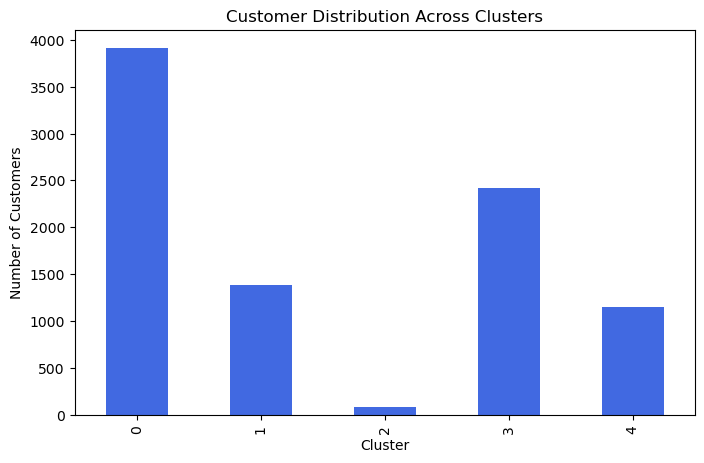

In [55]:
plt.figure(figsize=(8,5))

df["Cluster"].value_counts().sort_index().plot(
    kind="bar",
    color="royalblue"
)

plt.title("Customer Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

In [56]:
cluster_summary = df.groupby("Cluster").mean().round(2)

cluster_summary

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,1050.11,0.80,278.94,225.82,53.33,618.40,0.16,0.10,0.07,0.12,2.20,2.95,3342.97,1006.23,557.36,0.07,11.46
1,1904.69,0.98,2925.21,1988.68,936.96,360.61,0.92,0.73,0.59,0.06,1.17,43.62,6986.64,2789.12,832.82,0.27,11.88
2,4516.37,0.98,15897.09,10780.89,5116.20,1039.84,0.93,0.77,0.78,0.08,2.86,130.44,12451.76,15564.00,3344.43,0.40,11.96
3,644.40,0.90,797.10,167.28,630.32,178.02,0.86,0.08,0.79,0.04,0.71,16.64,3197.60,935.29,669.99,0.27,11.46
4,4604.35,0.97,485.15,298.43,186.81,4610.56,0.28,0.13,0.18,0.49,14.63,7.29,7528.75,3578.09,2014.61,0.04,11.38
